# [1] Process dataset to desired format

Keep the original dataset in `data_raw` folder and preprocess to save within `data` folder. 
Availibility of **output & GT_annotation** parameter is Optional. Latter can be set to random number between 1-5 for the sake of default formating, though not needed.
Any dataset for evaluation can have the following 2 types of structure:
1. wherein you have a pair of {input-output} NL for evaluation,
 - Translation - **input**: source NL, **output**: translated NL
 - Summarization - **input**: article, **output**: summary
2. wherein you have only 1 NL or multiple pair of input-output pair stored in input parameter for evaluation,
 - Instruct Excel - **input**: query NL
 - Formula Explanation - **input**: [['Formula_1', 'Explanation_1'], ['Formula_2', 'Explanation_2'], ...]

In [23]:
import os, json, pandas as pd, tqdm, random

def scaled(score, max_val, min_val=0):
    '''
    input: score: float: raw score
    description: normalize the raw score to the range of 1-5 using min-max scaling
    return: float: scaled score [1-5]
    '''
    return 1 + ((score-min_val)/(max_val-min_val))*4

def raise_error():
    raise ValueError("Dataset not in the required format. Please update the dataset and try again.")

def check_data(data):
    '''
    input: data: list of dictionaries: raw dataset
    description: check if the dataset is in the required format
    return: error_flag: bool: True if the dataset is not in the required format
    '''
    assert len(data)>0, "Dataset is empty"
    flag = False
    for d in data:
        for col in ['input']: # 'GT_annotation', 'output']:
            if col not in d:
                flag=True
                print(f"{col} missing in the dataset")
                raise_error()
        '''Optional columns'''
        # for asp in d['GT_annotation']:
        #     if d['GT_annotation'][asp] < 1 or d['GT_annotation'][asp] > 5:
        #         flag=True
        #         print("GT annotation should be in the range of 1-5")
        #         raise_error()
        for col in ['input']: #, 'output']:
            if type(d[col]) not in [str, list]:
                flag=True
                print(f"{col} is not of string or list format")
                raise_error()
        if d['input'] in ['',[]]:
            flag=True
            print("Input is empty")
            raise_error()
        if flag: break
    return flag


In [24]:
def load_dataset(filename):
    '''
    input: filename: str: path to the file
    description: load the dataset from the given file. Dataset can be in jsonl, csv or json format
    return: data: list of dictionaries: raw dataset
    '''
    if os.path.exists(filename.replace('data_raw', 'data')):
        print("Preprocessed data already exists. Skipping preprocessing step")
        return None

    if not os.path.exists(filename):
        print("File not found: ", filename)
        raise FileNotFoundError
    
    if filename.endswith('.jsonl'):
        data = []
        with open(filename, 'r', encoding='utf-8') as f:
            for line in tqdm.tqdm(f, desc="Loading JSONL data"):
                data.append(json.loads(line.strip()))
    elif filename.endswith('.csv'):
        data = pd.read_csv(filename, encoding='utf-8').to_dict(orient='records')
    elif filename.endswith('.json'):
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)
    elif filename.endswith('.txt'):
        data = []
        with open(filename, 'r', encoding='utf-8') as f:
            for line in tqdm.tqdm(f, desc="Loading TXT data"):
                data.append({'query': line.strip()})
    else:
        print("Invalid file format. Either update the code or Please provide a valid file format: jsonl, csv or json")
        raise ValueError
    
    return data

def preprocess_data(filename):
    '''
    input: filename: str: path to the file
    description: preprocess the dataset and stores in `data` folder, in the required format
    return: None
    '''
    data = load_dataset(filename)
    if data is None: return # Preprocessed data already exists. Skipping preprocessing step
    print("Total number of samples:", len(data))

    ##### UPDATE THE CODE WRT YOUR DATASET #####
    result=[]
    # max_val=0; min_val=100
    # '''if scores availiable'''
    # for d in tqdm.tqdm(data): # find the range of scale of values for the scores
    #     max_val = max(max_val, d['raw'])
    #     min_val = min(min_val, d['raw'])

    for d in tqdm.tqdm(data):
        temp={}
        '''if the dataset has input-output pair'''
        # temp['input'] = d['src']
        # temp['output'] = d['mt']
        '''if in your dataset, the evaluation is only 1 NL or multiple pairs then store in input parameter only:'''
        # given the dataset has only query parameter to evaluate on
        temp['input'] = d['query']

        # given annotation is available, store in GT_annotation
        ## in case of multiple aspects, append other aspects also ...
        ## in case of no aspect, put the aspect key as 'na'
        # temp['GT_annotation'] = {"overall": scaled(d['raw'], max_val, min_val)}

        '''if annotation is not available, set the score as any random number from 1-5:'''
        # temp['GT_annotation'] = {"overall": scaled(random.uniform(0, 100), 100, 0)}
        
        '''You can store any other information as metadata, as required: like id, filepath, lang ...'''
        temp['id'] = d['id']

        result.append(temp)
    #############################################

    if check_data(result): return # if dataset not in the required format, then dont save it

    # save the preprocessed data in jsonl format in data folder
    print("Example input:", result[0])
    with open(filename.replace('data_raw', 'data'), 'w', encoding='utf-8') as f:
        for d in result:
            f.write(json.dumps(d, ensure_ascii=False) + '\n')

    return 

In [25]:
basefile = os.getcwd()
input_filename = os.path.join(basefile, 'data_raw', 'example_data.jsonl')
preprocess_data(input_filename)

Loading JSONL data: 87it [00:00, 87151.77it/s]


Total number of samples: 87


100%|██████████| 87/87 [00:00<?, ?it/s]

Example input: {'input': 'Apply conditional formatting to cell M8-M14 of 7a sheet', 'id': 0}


# [2] Run AutoChecklist pipeline to generate checklist
`python -m script.checklist_generate --task "instruct_excel" --dataset_path "example_data.jsonl"`

Ensure you have all libraries in `requirements.txt` is installed. To generate the checklist run checklist_generate script, with the flexibility of what arguments you want to chose:
 - `python -m script.checklist_generate --<parameter> <value>`

Here is a details description on each of the parameters with examples:
- **task**: str; Short description of what task of input is provided; Example: ['translation', 'summarization', ...]
- **dataset_path**: str; Path to file containing input data in *data* folder; Example: ['example_translation.jsonl', ...]

*[Optional parameters]*
- **aspects**: str; default="[]", List of string of aspects over which checklist is to be built; Example: "['accuracy', 'overall', 'fluency', ...]". By-None: it assumes the aspects present within the GT_annotation parameter of dataset. In case of "[]": signifies no aspect to be used.
- **custom_checklist**: str; default="", Path to the manually curated seed checklist to set as starting point 
- **response_type**: int; default=0, Flag to note if response is of rating [1-5] (mentioned (Likert scale)-1, not-mentioned-2) or boolean(0) [yes/no] type for each question in checklist. By mentioned/non-mentioned we mean that within the prompt will we be mentioning the response to be of Likert scale of 1-5 with defination of each scale or not.
- **stoping_iteration**: int; default=5, Max number of iterations to run the script before stoping
- **llm**: str; default="gpt-4o-chat-completions", which LLM (chat/completion) endpoint from your LLM provider is to be used for pipeline (a model name containing 'chat' routes to the chat endpoint; see the `call_llm` placeholder in `script/prompting.py`); Example: ["gpt-4-1106", ...]


- **metachecklist**: str; default="helper/metachecklist.txt", File path to txt file with list of metachecklist criteria that each checklist should additionally follow. If do not want to se metachecklist leave the parameter-""(as empty string)
- **calling_prune**: int; default=1, Falgs if we are to use the pruning prompt after each aggregated checklist update iteratively (3), twice at the end (2), only once at the end (1), or not to prune at all (0)
- **prune_version**: int; default=2, Version of pruning prompt that is to be used. [Version (1)-4step instruction of sequentially arranging, removing similar, clustering and combining. Version (2)-2step instruction of latter 2 steps. Version (3)-no steps just instructed to remove redundant/dupplicate and combine similar.]
- **update_version**: int; default=1, Version of prompt to update checklist that is to be used. [Version (1)-produce modified checklist, Version (2)-produce only next appending checks generated from comments.]
- **seed_w_sample**: int; default=0, Flags if we are to generate the seed checklist while keeping 3 sample inputs in mind or not (0). Wherein if you are to select samples then: (1) stands for diverse samples, (2) for random samples, (3) high scoring samples, (4) low scoring samples
- **save_all**: bool; default=True, Debug mode to save all intermediate steps


You can play around with the parameters to generate variety of checklists. Here is an example of running this pipeline:
- `python -m script.checklist_generate --task "instruct_excel" --dataset_path "example_data.jsonl"`

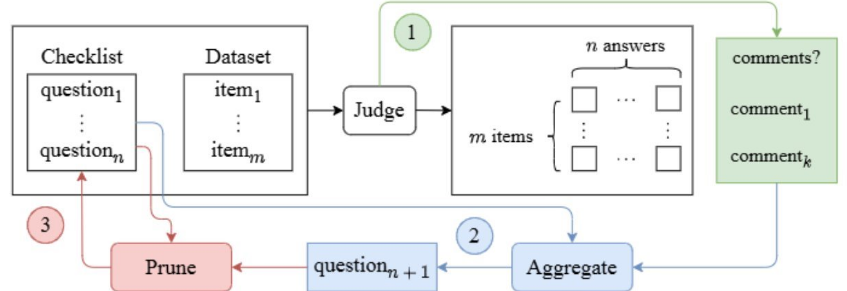

# [3] Getting annotated responses using checklist
`python -m script.annotate --task "instruct_excel" --dataset_path "example_data.jsonl"`

Once you have the final checklist, you can either chose to modify or use that for generating the annotated responses over the dataset. The final checklist generated, `output/checklist.json`, provides a good starting point for evaluation. You can choose to modify the json, by removing or adding new questions in the checklist, based on your domain expertise and level of liniency in error capturing of inputs. 

Once you are statisfied with the checklist, run the annotate script to get the evaluated responses over the input data, using the final checklist. These annotated responses gives scores on scale of [1-5], and stored in `output/annotations.json`. Here is an example of the running the code:
 - `python -m script.annotate --task "instruct_excel" --dataset_path "example_data.jsonl"` 
 
The parameters that you can play with are:
- **task**: str; Short description of what task of input is provided; Example: ['translation', 'summarization', ...]
- **dataset_path**: str; Path to file containing input data in *data* folder; Example: ['example_translation.jsonl', ...]

*[Optional parameters]*
- **output_path**: str; default="output/annotate.jsonl", Path to store the final annotations
- **custom_checklist**: str; default="output/checklist.json", Path to the manually curated seed checklist to set as starting point 
- **llm**: str; default="gpt-4o-chat-completions", which LLM (chat/completion) endpoint from your LLM provider is to be used for pipeline (a model name containing 'chat' routes to the chat endpoint; see the `call_llm` placeholder in `script/prompting.py`); Example: ["gpt-4-1106", ...]
- **dataset_size**: int; default=None, How mny of the initial samples are to be annotated, None: means for all input samples


This `annotated.jsonl` file would add in parameters of **aggregated score** [1-5] ([0-3] for case of instruct excel explicitly), **full_response** that is the Yes/No responses for each of the checklist question.


**NOTE:**

---  Here no comments will be generated as we only want final annotation from the checklist and are not prompting to generate comments as we are not updating the checklist further.

---  Don't mind the "na" keys in aggregated_scores or full_responses. It denotes that the checklist does not evaluate on any specific aspect for the given task, but generates the responses keeping overall view in context.
